In [1]:
from itscalledsoccer.client import AmericanSoccerAnalysis
from plotnine import *
from colour import Color
import numpy as np
import pandas as pd

import numpy as np
from collections import defaultdict

import matplotlib.pyplot as plt

asa_client = AmericanSoccerAnalysis()
from sophso import decorate_team_ids, nwsl_primary_colors

In [2]:
def get_games(leagues="nwsl", seasons="2024"):

    games_df = decorate_team_ids(asa_client.get_games(leagues=leagues, seasons=seasons))
    gxg_df = asa_client.get_game_xgoals(game_ids=list(games_df.game_id))

    games_df = games_df.merge(
        gxg_df[
            [
                "game_id",
                "home_team_xgoals",
                "away_team_xgoals",
                "home_xpoints",
                "away_xpoints",
            ]
        ],
        on="game_id",
    )

    games_df = games_df.sort_values("date_time_utc", ignore_index=True)

    return games_df

Elo is a system for estimating player or team strength in zero sum games.

It's been adapted for use in soccer across the world. There are a variety of approaches that are all based on a similar formula

$R_n = R_o + P$
and
$P = K G (W - W_e)$

where

- $R_n$ The new team rating
- $R_o$ The old team rating
- $K$ Weight index regarding the tournament of the match
- $G$ A number from the index of goal differences
- $W$ The result of the match
- $W_e$ The expected result
- $P$ Points Change

Below I build a model that tests a few different changes and settings:

- First, inspired by [Trevor Larner](https://bsky.app/profile/trevorl.bsky.social) I want to determine if using xG to determine the outcome of matches rather than goals scored results in a better model.
- To do this, I will optimize both version of the model (score vs xg) so that we can compare the predictive abilities of each under relatively optimal conditions. To do this I will perform a grid search over the following parameters:
  - home rating: a parameter that adds to rating of home teams to reflect a "home field advantage"
  - k: the weight index, which determins how much ratings should change based on the result of a match
  - goal diff draw: this determins how much greater the xg value must be in order for a game to be considered a win.


In [3]:
def elo_learn(
    games_df,
    k=10,
    rating_start=150,
    home_points=2,
    scaling_factor=100,
    learn_input="score",
    goal_diff_draw=0.25,
):

    team_ratings = defaultdict(lambda: rating_start)

    for row, game in games_df.iterrows():

        if learn_input == "score":
            goal_diff = game.home_score - game.away_score
        elif learn_input == "xg":
            goal_diff = game.home_team_xgoals - game.away_team_xgoals
        else:
            raise ("learn_input must be either 'score' or 'xg'")

        rating_diff = (
            team_ratings[game.home_team] - team_ratings[game.away_team] + home_points
        )
        expected_result = 1 / (1 + 10 ** (-rating_diff / scaling_factor))

        if abs(goal_diff) <= 1:
            goal_index = 1
        elif abs(goal_diff) < 3:
            goal_index = (1 + abs(goal_diff)) / 2
        else:
            goal_index = (11 + abs(goal_diff)) / 8

        if abs(goal_diff) < goal_diff_draw:
            result = 0.5
        else:
            result = goal_diff / abs(goal_diff)

        points_change = k * goal_index * (result - expected_result)

        team_ratings[game.home_team] = team_ratings[game.home_team] + points_change
        team_ratings[game.away_team] = team_ratings[game.away_team] - points_change

    ratings_df = pd.DataFrame(team_ratings.items(), columns=["team", "rating"])

    return ratings_df

In [4]:
def get_predictions(ratings_df, games_df, home_points=2, scaling_factor=100, **kwargs):

    ratings_map = dict(zip(ratings_df.team, ratings_df.rating))

    ratings_diff = (
        games_df.home_team.map(ratings_map)
        - games_df.away_team.map(ratings_map)
        + home_points
    )

    home_prob = 1 / (1 + 10 ** (-ratings_diff / scaling_factor))
    games_df["home_prob"] = home_prob

    return games_df

In [5]:
def process_result(games_df):

    games_df["result"] = 0.0
    games_df.loc[games_df.home_score == games_df.away_score, "result"] = 0.5
    games_df.loc[games_df.home_score > games_df.away_score, "result"] = 1

    return games_df

In [6]:
def evaluate_params(train_df, test_df, **params):

    ratings_df = elo_learn(games_df=train_df, **params)

    test_df = get_predictions(ratings_df, games_df=test_df, **params)

    test_df = process_result(test_df)

    return -np.mean(
        test_df.result * np.log(test_df.home_prob)
        + (1 - test_df.result) * np.log(1 - test_df.home_prob)
    )

In [7]:
# 2019-2024 was the most seasons I could fit into a single request.
# TODO: figure out how to include 2016 and on

games_df = get_games(
    leagues="nwsl",
    seasons=[
        "2019",
        "2020",
        "2021",
        "2022",
        "2023",
        "2024",
    ],
)

games_df.home_team = games_df.home_team + games_df.season_name.astype(str)
games_df.away_team = games_df.away_team + games_df.season_name.astype(str)


games_df.groupby("season_name").matchday.max()

season_name
2019    27
2020     8
2021    25
2022    23
2023    25
2024    29
Name: matchday, dtype: int64

In [8]:
train_mask = (
    (games_df.season_name == 2019) & (games_df.matchday <= 10)
    | ((games_df.season_name == 2020) & (games_df.matchday <= 4))
    | ((games_df.season_name == 2021) & (games_df.matchday <= 10))
    | ((games_df.season_name == 2022) & (games_df.matchday <= 10))
    | ((games_df.season_name == 2023) & (games_df.matchday <= 10))
    | ((games_df.season_name == 2024) & (games_df.matchday <= 10))
)

train_df = games_df.loc[train_mask, :].copy()
test_df = games_df.loc[~train_mask, :].copy()

train_mask.mean()

0.49522673031026254

So we have 58% of games in the training set and the remainder in test.

The way I'll evaluate each Elo model is by training the model on the first set of games and then using it to predict the outcome of games in the test set.

To simplify things, I'm going to gloss over draws. I'll treat the output of the Elo model as a raw win percentage. When evaluating performance against the true outcome of games, I will treat wins as an outcome of 1, losses as an outcome of 0, and draws as 0.5.

This approach allows me to use [cross entropy](https://en.wikipedia.org/wiki/Cross-entropy) to evaluate the performance of each model.


# score

First, let's look at the performance of the Elo model that awards ratings based on raw score.


2.4489795918367347

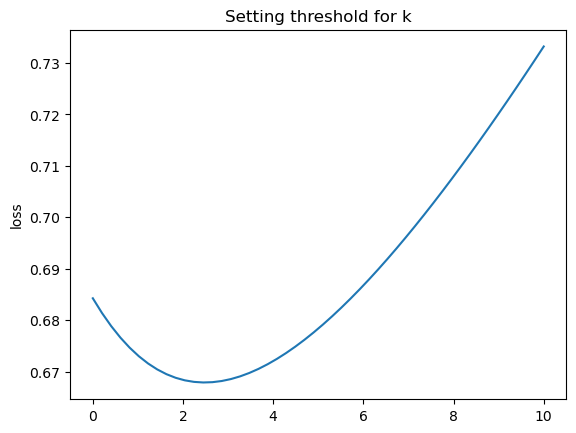

In [9]:
params = dict(home_points=10, k=2.5, scaling_factor=100, learn_input="score")

k_range = np.linspace(0, 10, 50)
log_loss = []

for k in k_range:

    params["k"] = k

    log_loss += [evaluate_params(train_df, test_df, **params)]


plt.plot(k_range, log_loss)
plt.title("Setting threshold for k")
plt.ylabel("loss")

k_range[np.argmin(log_loss)]

11.4

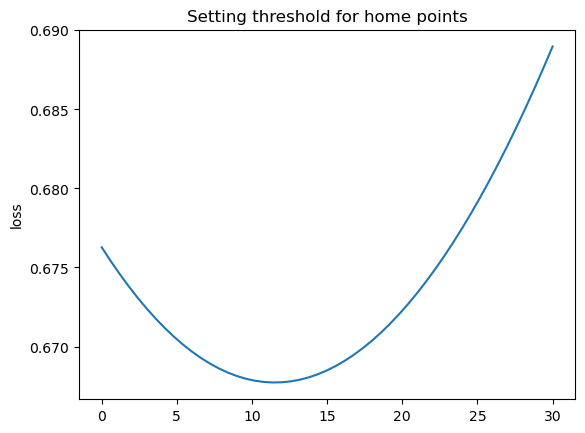

In [10]:
params = dict(home_points=10, k=2.5, scaling_factor=100, learn_input="score")

home_points_range = np.linspace(0, 30, 51)
log_loss = []

for home_points in home_points_range:

    params["home_points"] = home_points

    log_loss += [evaluate_params(train_df, test_df, **params)]


plt.plot(home_points_range, log_loss)
plt.title("Setting threshold for home points")
plt.ylabel("loss")

home_points_range[np.argmin(log_loss)]

For a score-based Elo model, we find the best performance with $k=20$ and a home rating of 15.


In [11]:
params = dict(home_points=10, k=2.5, scaling_factor=100, learn_input="score")

games_df = get_games(leagues="nwsl", seasons="2025")

ratings_df = elo_learn(games_df, **params)

ratings_df.sort_values("rating", ascending=False, ignore_index=True)

,team,rating
0,KC,179.107798
1,SD,163.473414
2,ORL,162.678329
3,POR,161.476637
4,SEA,157.372387
5,NJY,156.904011
6,WAS,156.144043
7,NC,151.190944
8,LOU,147.036722
9,BAY,145.516869


# xg

Now for the xG model. One thing to note here is that we have an additional parameter to tune. Typically this is considered to give models an advantage. We'll need to keep that in mind


0.03232323232323232

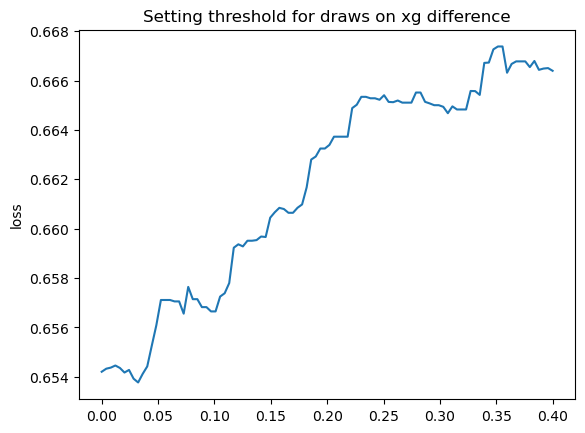

In [12]:
params = dict(
    home_points=10, k=2.5, scaling_factor=100, learn_input="xg", goal_diff_draw=0.35
)

goal_diff_draw_range = np.linspace(0, 0.4, 100)
log_loss = []

for goal_diff_draw in goal_diff_draw_range:

    params["goal_diff_draw"] = goal_diff_draw

    log_loss += [evaluate_params(train_df, test_df, **params)]


plt.plot(goal_diff_draw_range, log_loss)
plt.title("Setting threshold for draws on xg difference")
plt.ylabel("loss")


goal_diff_draw_range[np.argmin(log_loss)]

There's a space of low loss for xg draw thresholds between ~0.35-0.4. I'll choose 0.35 for now.


2.857142857142857

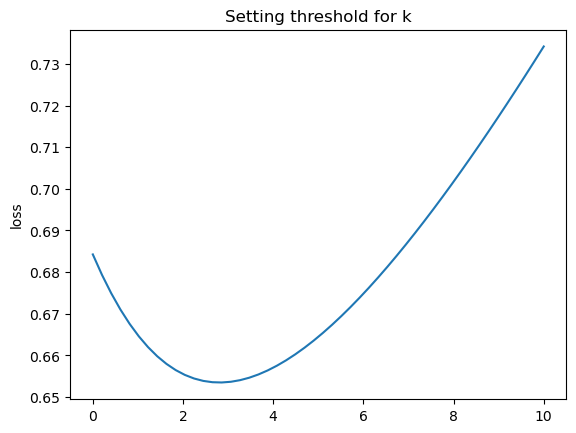

In [13]:
params = dict(
    home_points=10, k=2.5, scaling_factor=100, learn_input="xg", goal_diff_draw=0.03
)

k_range = np.linspace(0, 10, 50)
log_loss = []

for k in k_range:

    params["k"] = k

    log_loss += [evaluate_params(train_df, test_df, **params)]


plt.plot(k_range, log_loss)
plt.title("Setting threshold for k")
plt.ylabel("loss")
k_range[np.argmin(log_loss)]

12.0

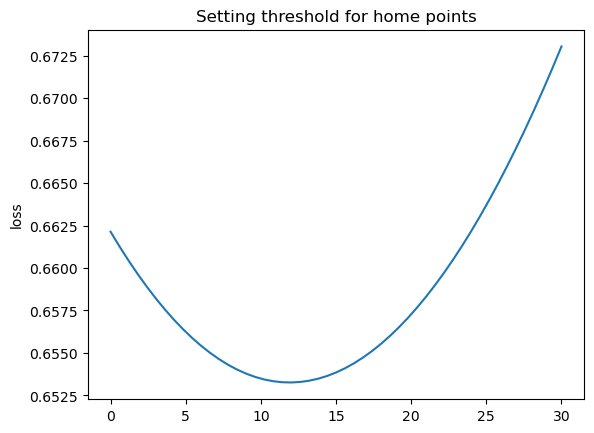

In [14]:
params = dict(
    home_points=10, k=2.8, scaling_factor=100, learn_input="xg", goal_diff_draw=0.03
)

home_points_range = np.linspace(0, 30, 51)
log_loss = []

for home_points in home_points_range:

    params["home_points"] = home_points

    log_loss += [evaluate_params(train_df, test_df, **params)]


plt.plot(home_points_range, log_loss)
plt.title("Setting threshold for home points")
plt.ylabel("loss")
home_points_range[np.argmin(log_loss)]

# Comparison


In [ ]:
params = dict(
    home_points=12, k=2.5, scaling_factor=100, learn_input="score", goal_diff_draw=0.03
)

print(
    f"""Score-based Elo model
cross entropy (2019-2024): {evaluate_params(train_df, test_df, **params):.4f}
2025 team ratings:"""
)

games_df = get_games(leagues="nwsl", seasons="2025")

ratings_df = elo_learn(games_df, **params)

ratings_df.sort_values("rating", ascending=False, ignore_index=True)

Score-based Elo model
cross entropy (2019-2024): 0.6677
2025 team ratings:


,team,rating
0,KC,179.118125
1,SD,163.451909
2,ORL,162.707945
3,POR,161.453911
4,SEA,157.420039
5,NJY,156.984948
6,WAS,156.171751
7,NC,151.261058
8,LOU,146.980830
9,BAY,145.543426


In [16]:
params = dict(
    home_points=11, k=2.8, scaling_factor=100, learn_input="xg", goal_diff_draw=0.01
)

print(
    f"""xG-based Elo model
cross entropy (2019-2024): {evaluate_params(train_df, test_df, **params):.4f}
2025 team ratings:"""
)

games_df = get_games(leagues="nwsl", seasons="2025")

ratings_df = elo_learn(games_df, **params)

ratings_df.sort_values("rating", ascending=False, ignore_index=True)

xG-based Elo model
cross entropy (2019-2024): 0.6541
2025 team ratings:


,team,rating
0,KC,190.723412
1,POR,169.277044
2,LOU,161.552449
3,NJY,160.806857
4,NC,159.956642
5,ORL,157.478367
6,SD,150.583507
7,BAY,150.528480
8,WAS,145.282048
9,SEA,143.737332


# Takeaways

The two approachs---raw score vs xG---for estimating team strength perform similarly well, with the xG model perfoming slightly better (0.654 vs 0.668). Because the xG model has an additional free parameter, I'm not ready to say based on this alone that using xG to estimate team strength is strictly superior to using the outcome of games.

However, the fact that using xG is a functional way to estimate team strength at all seems notable to me! xG may not win you games itself, but it does appear to measure something with a strong relationship to team strength---potentially even stronger than the actual outcome of games played!

It's also notable to me that the winning parameters for both the xG and score based models were so similar across 5 seasons of data. Some conclusions form the model:

- there appears to be a home feild advantage worth 10 Elo points. Equivalent to a ~ 10% greater chance of winning (assuming no draws)
- the most predictive "weight index" for NWSL regular season games is 2.5.
- for the best performing xG model, any xG difference below 0.03 is treated as a draw.


In [17]:
 1 / (1 + 10 ** ((-2)/100))

0.5115108912177917

In [18]:
0.49 * 0.75

0.3675

In [19]:
ratings_df

,team,rating
0,ORL,157.478367
1,WAS,145.282048
2,CHI,126.249197
3,HOU,132.432857
4,KC,190.723412
5,POR,169.277044
6,UTA,120.034280
7,BAY,150.528480
8,LOU,161.552449
9,NC,159.956642


In [20]:
prematch_df = get_predictions(
    ratings_df=ratings_df,
    games_df=decorate_team_ids(
        asa_client.get_games(leagues="nwsl", seasons="2025", status="PreMatch")
    ),
    **params
)

prematch_df

,game_id,date_time_utc,home_team_id,away_team_id,stadium_id,season_name,matchday,knockout_game,status,home_team,home_team_logo,away_team,away_team_logo,home_prob
0,0x5gjnorM7,2025-11-02 20:00:00 UTC,Pk5LeeNqOW,4JMAk47qKg,p6qbX06M0G,2025,26,False,PreMatch,POR,https://american-soccer-analysis-headshots.s3....,HOU,https://american-soccer-analysis-headshots.s3....,0.750570
4,KAqBbOVJqb,2025-11-02 20:00:00 UTC,zeQZeazqKw,raMyrr25d2,gpMOrLOQzy,2025,26,False,PreMatch,NC,https://american-soccer-analysis-headshots.s3....,NJY,https://american-soccer-analysis-headshots.s3....,0.558162
6,Oa5wj2OjM1,2025-11-02 20:00:00 UTC,KPqjw8PQ6v,kRQa8JOqKZ,9YqdkYR5vJ,2025,26,False,PreMatch,CHI,https://american-soccer-analysis-headshots.s3....,LA,https://american-soccer-analysis-headshots.s3....,0.533863
5,NWMWp4875l,2025-11-02 20:00:00 UTC,XVqKeVKM01,7vQ7BBzqD1,vzqoJrj5ap,2025,26,False,PreMatch,ORL,https://american-soccer-analysis-headshots.s3....,SEA,https://american-soccer-analysis-headshots.s3....,0.638690
1,7VqGbYNe5v,2025-11-02 20:00:00 UTC,eV5D2w9QKn,aDQ0lzvQEv,e7MzlRjqr0,2025,26,False,PreMatch,UTA,https://american-soccer-analysis-headshots.s3....,WAS,https://american-soccer-analysis-headshots.s3....,0.418711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,eV5Dpo0A5K,2025-08-03 02:00:00 UTC,315VnJ759x,4JMAk47qKg,Vj58W84M8n,2025,14,False,PreMatch,BAY,https://american-soccer-analysis-headshots.s3....,HOU,https://american-soccer-analysis-headshots.s3....,0.661492
87,7vQ7bj32qD,2025-08-02 23:30:00 UTC,zeQZeazqKw,7VqG1lYMvW,gpMOrLOQzy,2025,14,False,PreMatch,NC,https://american-soccer-analysis-headshots.s3....,SD,https://american-soccer-analysis-headshots.s3....,0.615173
88,raMyj2ZO5d,2025-08-02 02:30:00 UTC,7vQ7BBzqD1,kRQa8JOqKZ,9Yqda07QvJ,2025,14,False,PreMatch,SEA,https://american-soccer-analysis-headshots.s3....,LA,https://american-soccer-analysis-headshots.s3....,0.631426
89,gjMNpdv0qK,2025-08-02 00:00:00 UTC,eV5DR6YQKn,4wM4rZdqjB,BLMvra8Mxe,2025,14,False,PreMatch,LOU,https://american-soccer-analysis-headshots.s3....,KC,https://american-soccer-analysis-headshots.s3....,0.396899


In [21]:
prematch_df.query("(home_team == 'LOU') | (away_team == 'LOU')").sort_values(
    "date_time_utc"
)

,game_id,date_time_utc,home_team_id,away_team_id,stadium_id,season_name,matchday,knockout_game,status,home_team,home_team_logo,away_team,away_team_logo,home_prob
89,gjMNpdv0qK,2025-08-02 00:00:00 UTC,eV5DR6YQKn,4wM4rZdqjB,BLMvra8Mxe,2025,14,False,PreMatch,LOU,https://american-soccer-analysis-headshots.s3....,KC,https://american-soccer-analysis-headshots.s3....,0.396899
80,KXMeZ6Or56,2025-08-09 23:30:00 UTC,XVqKeVKM01,eV5DR6YQKn,vzqoJrj5ap,2025,15,False,PreMatch,ORL,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.539785
76,aDQ0b2PP5E,2025-08-16 00:00:00 UTC,aDQ0lzvQEv,eV5DR6YQKn,xW5pwORMg1,2025,16,False,PreMatch,WAS,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.469698
63,Xj5Ypd6AMb,2025-08-25 00:00:00 UTC,7VqG1lYMvW,eV5DR6YQKn,Oa5wKXY514,2025,17,False,PreMatch,SD,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.500179
62,jYQJmLzPqG,2025-08-29 23:30:00 UTC,eV5DR6YQKn,4JMAk47qKg,BLMvra8Mxe,2025,18,False,PreMatch,LOU,https://american-soccer-analysis-headshots.s3....,HOU,https://american-soccer-analysis-headshots.s3....,0.715813
55,0Oq6bZwAq6,2025-09-06 00:00:00 UTC,eV5DR6YQKn,Pk5LeeNqOW,BLMvra8Mxe,2025,19,False,PreMatch,LOU,https://american-soccer-analysis-headshots.s3....,POR,https://american-soccer-analysis-headshots.s3....,0.518846
42,gpMOpdan5z,2025-09-15 00:00:00 UTC,7vQ7BBzqD1,eV5DR6YQKn,9Yqda07QvJ,2025,20,False,PreMatch,SEA,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.460849
38,wvq9b8gZQW,2025-09-20 02:00:00 UTC,eV5D2w9QKn,eV5DR6YQKn,e7MzlRjqr0,2025,21,False,PreMatch,UTA,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.331212
31,7vQ7bjYYqD,2025-09-27 23:30:00 UTC,eV5DR6YQKn,kRQa8JOqKZ,BLMvra8Mxe,2025,22,False,PreMatch,LOU,https://american-soccer-analysis-headshots.s3....,LA,https://american-soccer-analysis-headshots.s3....,0.720823
26,Vj58bpy3Q8,2025-10-04 23:30:00 UTC,zeQZeazqKw,eV5DR6YQKn,gpMOrLOQzy,2025,23,False,PreMatch,NC,https://american-soccer-analysis-headshots.s3....,LOU,https://american-soccer-analysis-headshots.s3....,0.553924
